<a href="https://colab.research.google.com/github/Lucas-Bas/Aluraplus/blob/main/An%C3%A1lise_de_dados_com_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
url = 'https://github.com/alura-cursos/python-analise-chatgpt-assistente/raw/main/Dados/dados_vendas.json'

In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_json(url)
df.head()

,item_identificador,loja_identificador,vendas_totais,item,loja
0,FDB08,OUT018,176503.58,"{'item_peso': 6.055, 'item_conteudo_gordura': ...","{'loja_ano_estabelecimento': 2019, 'loja_taman..."
1,DRQ35,OUT049,185758.20,"{'item_peso': 9.3, 'item_conteudo_gordura': 'B...","{'loja_ano_estabelecimento': 2009, 'loja_taman..."
2,FDD14,OUT018,165983.94,"{'item_peso': 20.7, 'item_conteudo_gordura': '...","{'loja_ano_estabelecimento': 2019, 'loja_taman..."
3,FDY37,OUT045,314923.40,"{'item_peso': 17.0, 'item_conteudo_gordura': '...","{'loja_ano_estabelecimento': 2012, 'loja_taman..."
4,FDY59,OUT018,64782.34,"{'item_peso': 8.195, 'item_conteudo_gordura': ...","{'loja_ano_estabelecimento': 2019, 'loja_taman..."


In [4]:
# Importe a função json_normalize
from pandas import json_normalize

# Normalize os dados da coluna "item"
df_item_normalized = json_normalize(df['item'])

# Normalize os dados da coluna "loja"
df_loja_normalized = json_normalize(df['loja'])

# Combine os DataFrames normalizados com o DataFrame original
df = pd.concat([df, df_item_normalized, df_loja_normalized], axis=1)

# Exclua as colunas originais de "item" e "loja" se necessário
df.drop(['item', 'loja'], axis=1, inplace=True)
df

,item_identificador,loja_identificador,vendas_totais,item_peso,item_conteudo_gordura,item_visibilidade,item_tipo,item_preco,item_quantidade_venda,loja_ano_estabelecimento,loja_tamanho,loja_tipo_localizacao,loja_tipo
0,FDB08,OUT018,176503.58,6.055,Baixo Teor de Gordura,0.031230,Frutas e Vegetais,160.36,None,2019,Médio,Nível 3,Supermercado Tipo 2
1,DRQ35,OUT049,185758.20,9.300,Baixo Teor de Gordura,0.042357,Bebidas Alcoólicas,123.24,None,2009,Médio,Nível 1,Supermercado Tipo 1
2,FDD14,OUT018,165983.94,20.700,Baixo Teor de Gordura,0.170500,Enlatados,184.13,None,2019,Médio,Nível 3,Supermercado Tipo 2
3,FDY37,OUT045,314923.40,17.000,Regular,0.026623,Enlatados,144.25,None,2012,None,Nível 2,Supermercado Tipo 1
4,FDY59,OUT018,64782.34,8.195,Baixo Teor de Gordura,0.000000,Confeitaria,93.15,None,2019,Médio,Nível 3,Supermercado Tipo 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8545,FDY08,OUT010,28096.76,9.395,Regular,0.286345,Frutas e Vegetais,139.18,None,2008,None,Nível 3,Mercado
8546,FDC41,OUT017,130163.90,15.600,Baixo Teor de Gordura,0.117575,Alimentos Congelados,75.67,None,2017,None,Nível 2,Supermercado Tipo 1
8547,NCQ53,OUT045,614533.40,17.600,Baixo Teor de Gordura,0.018944,Mercearia,237.36,None,2012,None,Nível 2,Supermercado Tipo 1
8548,FDL46,OUT017,164985.24,20.350,baixo teor de gordura,0.054363,Lanches,117.95,None,2017,None,Nível 2,Supermercado Tipo 1


In [5]:
# Verificar as primeiras 5 linhas do DataFrame
df.head()

,item_identificador,loja_identificador,vendas_totais,item_peso,item_conteudo_gordura,item_visibilidade,item_tipo,item_preco,item_quantidade_venda,loja_ano_estabelecimento,loja_tamanho,loja_tipo_localizacao,loja_tipo
0,FDB08,OUT018,176503.58,6.055,Baixo Teor de Gordura,0.031230,Frutas e Vegetais,160.36,None,2019,Médio,Nível 3,Supermercado Tipo 2
1,DRQ35,OUT049,185758.20,9.300,Baixo Teor de Gordura,0.042357,Bebidas Alcoólicas,123.24,None,2009,Médio,Nível 1,Supermercado Tipo 1
2,FDD14,OUT018,165983.94,20.700,Baixo Teor de Gordura,0.170500,Enlatados,184.13,None,2019,Médio,Nível 3,Supermercado Tipo 2
3,FDY37,OUT045,314923.40,17.000,Regular,0.026623,Enlatados,144.25,None,2012,None,Nível 2,Supermercado Tipo 1
4,FDY59,OUT018,64782.34,8.195,Baixo Teor de Gordura,0.000000,Confeitaria,93.15,None,2019,Médio,Nível 3,Supermercado Tipo 2


In [6]:
# Resumo estatístico das colunas numéricas
df.describe()

,vendas_totais,item_peso,item_visibilidade,item_preco,loja_ano_estabelecimento
count,8.550000e+03,7081.000000,8550.000000,8550.000000,8550.000000
mean,2.181949e+05,12.855023,0.066150,141.007453,2007.830409
std,1.708098e+05,4.643508,0.051578,62.333062,8.372541
min,3.329000e+03,4.555000,0.000000,31.290000,1995.000000
25%,8.349132e+04,8.770000,0.027024,93.787500,1997.000000
50%,1.794331e+05,12.600000,0.053978,142.935000,2009.000000
75%,3.100963e+05,16.850000,0.094646,185.760000,2014.000000
max,1.308696e+06,21.350000,0.328391,266.890000,2019.000000


In [7]:
# Informações gerais sobre o DataFrame, incluindo tipos de dados e contagem de valores não nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8550 entries, 0 to 8549
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   item_identificador        8550 non-null   object 
 1   loja_identificador        8550 non-null   object 
 2   vendas_totais             8550 non-null   float64
 3   item_peso                 7081 non-null   float64
 4   item_conteudo_gordura     8550 non-null   object 
 5   item_visibilidade         8550 non-null   float64
 6   item_tipo                 8550 non-null   object 
 7   item_preco                8550 non-null   float64
 8   item_quantidade_venda     0 non-null      object 
 9   loja_ano_estabelecimento  8550 non-null   int64  
 10  loja_tamanho              6133 non-null   object 
 11  loja_tipo_localizacao     8550 non-null   object 
 12  loja_tipo                 8550 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 868.5+ KB


In [8]:
# Verificar a contagem de valores únicos em cada coluna
df.nunique()

,0
item_identificador,1559
loja_identificador,10
vendas_totais,3493
item_peso,415
item_conteudo_gordura,5
item_visibilidade,7880
item_tipo,16
item_preco,4839
item_quantidade_venda,0
loja_ano_estabelecimento,9


In [9]:
# Verificar se há valores duplicados no DataFrame
df.duplicated().sum()

np.int64(27)

In [10]:
# Verificar se há valores ausentes (NaN) em cada coluna
df.isnull().sum()

,0
item_identificador,0
loja_identificador,0
vendas_totais,0
item_peso,1469
item_conteudo_gordura,0
item_visibilidade,0
item_tipo,0
item_preco,0
item_quantidade_venda,8550
loja_ano_estabelecimento,0


In [11]:
df['item_conteudo_gordura'].unique()

array(['Baixo Teor de Gordura', 'Regular', 'BTG', 'reg',
       'baixo teor de gordura'], dtype=object)

In [12]:
df.drop_duplicates(inplace=True)
df

,item_identificador,loja_identificador,vendas_totais,item_peso,item_conteudo_gordura,item_visibilidade,item_tipo,item_preco,item_quantidade_venda,loja_ano_estabelecimento,loja_tamanho,loja_tipo_localizacao,loja_tipo
0,FDB08,OUT018,176503.58,6.055,Baixo Teor de Gordura,0.031230,Frutas e Vegetais,160.36,None,2019,Médio,Nível 3,Supermercado Tipo 2
1,DRQ35,OUT049,185758.20,9.300,Baixo Teor de Gordura,0.042357,Bebidas Alcoólicas,123.24,None,2009,Médio,Nível 1,Supermercado Tipo 1
2,FDD14,OUT018,165983.94,20.700,Baixo Teor de Gordura,0.170500,Enlatados,184.13,None,2019,Médio,Nível 3,Supermercado Tipo 2
3,FDY37,OUT045,314923.40,17.000,Regular,0.026623,Enlatados,144.25,None,2012,None,Nível 2,Supermercado Tipo 1
4,FDY59,OUT018,64782.34,8.195,Baixo Teor de Gordura,0.000000,Confeitaria,93.15,None,2019,Médio,Nível 3,Supermercado Tipo 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8545,FDY08,OUT010,28096.76,9.395,Regular,0.286345,Frutas e Vegetais,139.18,None,2008,None,Nível 3,Mercado
8546,FDC41,OUT017,130163.90,15.600,Baixo Teor de Gordura,0.117575,Alimentos Congelados,75.67,None,2017,None,Nível 2,Supermercado Tipo 1
8547,NCQ53,OUT045,614533.40,17.600,Baixo Teor de Gordura,0.018944,Mercearia,237.36,None,2012,None,Nível 2,Supermercado Tipo 1
8548,FDL46,OUT017,164985.24,20.350,baixo teor de gordura,0.054363,Lanches,117.95,None,2017,None,Nível 2,Supermercado Tipo 1


In [13]:
df.drop(columns=['item_quantidade_venda'], inplace=True)

In [14]:
df['item_peso'].fillna(df['item_peso'].mean(), inplace=True)

/tmp/ipykernel_7576/1116197996.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['item_peso'].fillna(df['item_peso'].mean(), inplace=True)


In [15]:
df['loja_tamanho'].fillna('Não registrado', inplace=True)


/tmp/ipykernel_7576/395754442.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loja_tamanho'].fillna('Não registrado', inplace=True)


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8523 entries, 0 to 8549
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   item_identificador        8523 non-null   object 
 1   loja_identificador        8523 non-null   object 
 2   vendas_totais             8523 non-null   float64
 3   item_peso                 8523 non-null   float64
 4   item_conteudo_gordura     8523 non-null   object 
 5   item_visibilidade         8523 non-null   float64
 6   item_tipo                 8523 non-null   object 
 7   item_preco                8523 non-null   float64
 8   loja_ano_estabelecimento  8523 non-null   int64  
 9   loja_tamanho              8523 non-null   object 
 10  loja_tipo_localizacao     8523 non-null   object 
 11  loja_tipo                 8523 non-null   object 
dtypes: float64(4), int64(1), object(7)
memory usage: 1.1+ MB


In [17]:
# Mapeie os valores não padronizados para os valores padronizados
mapeamento = {
    'BTG': 'Baixo Teor de Gordura',
    'reg': 'Regular',
    'baixo teor de gordura': 'Baixo Teor de Gordura'
}

# Use a função replace para substituir os valores na coluna
df['item_conteudo_gordura'] = df['item_conteudo_gordura'].replace(mapeamento)

# Verifique os valores únicos após a substituição
df['item_conteudo_gordura'].unique()

array(['Baixo Teor de Gordura', 'Regular'], dtype=object)

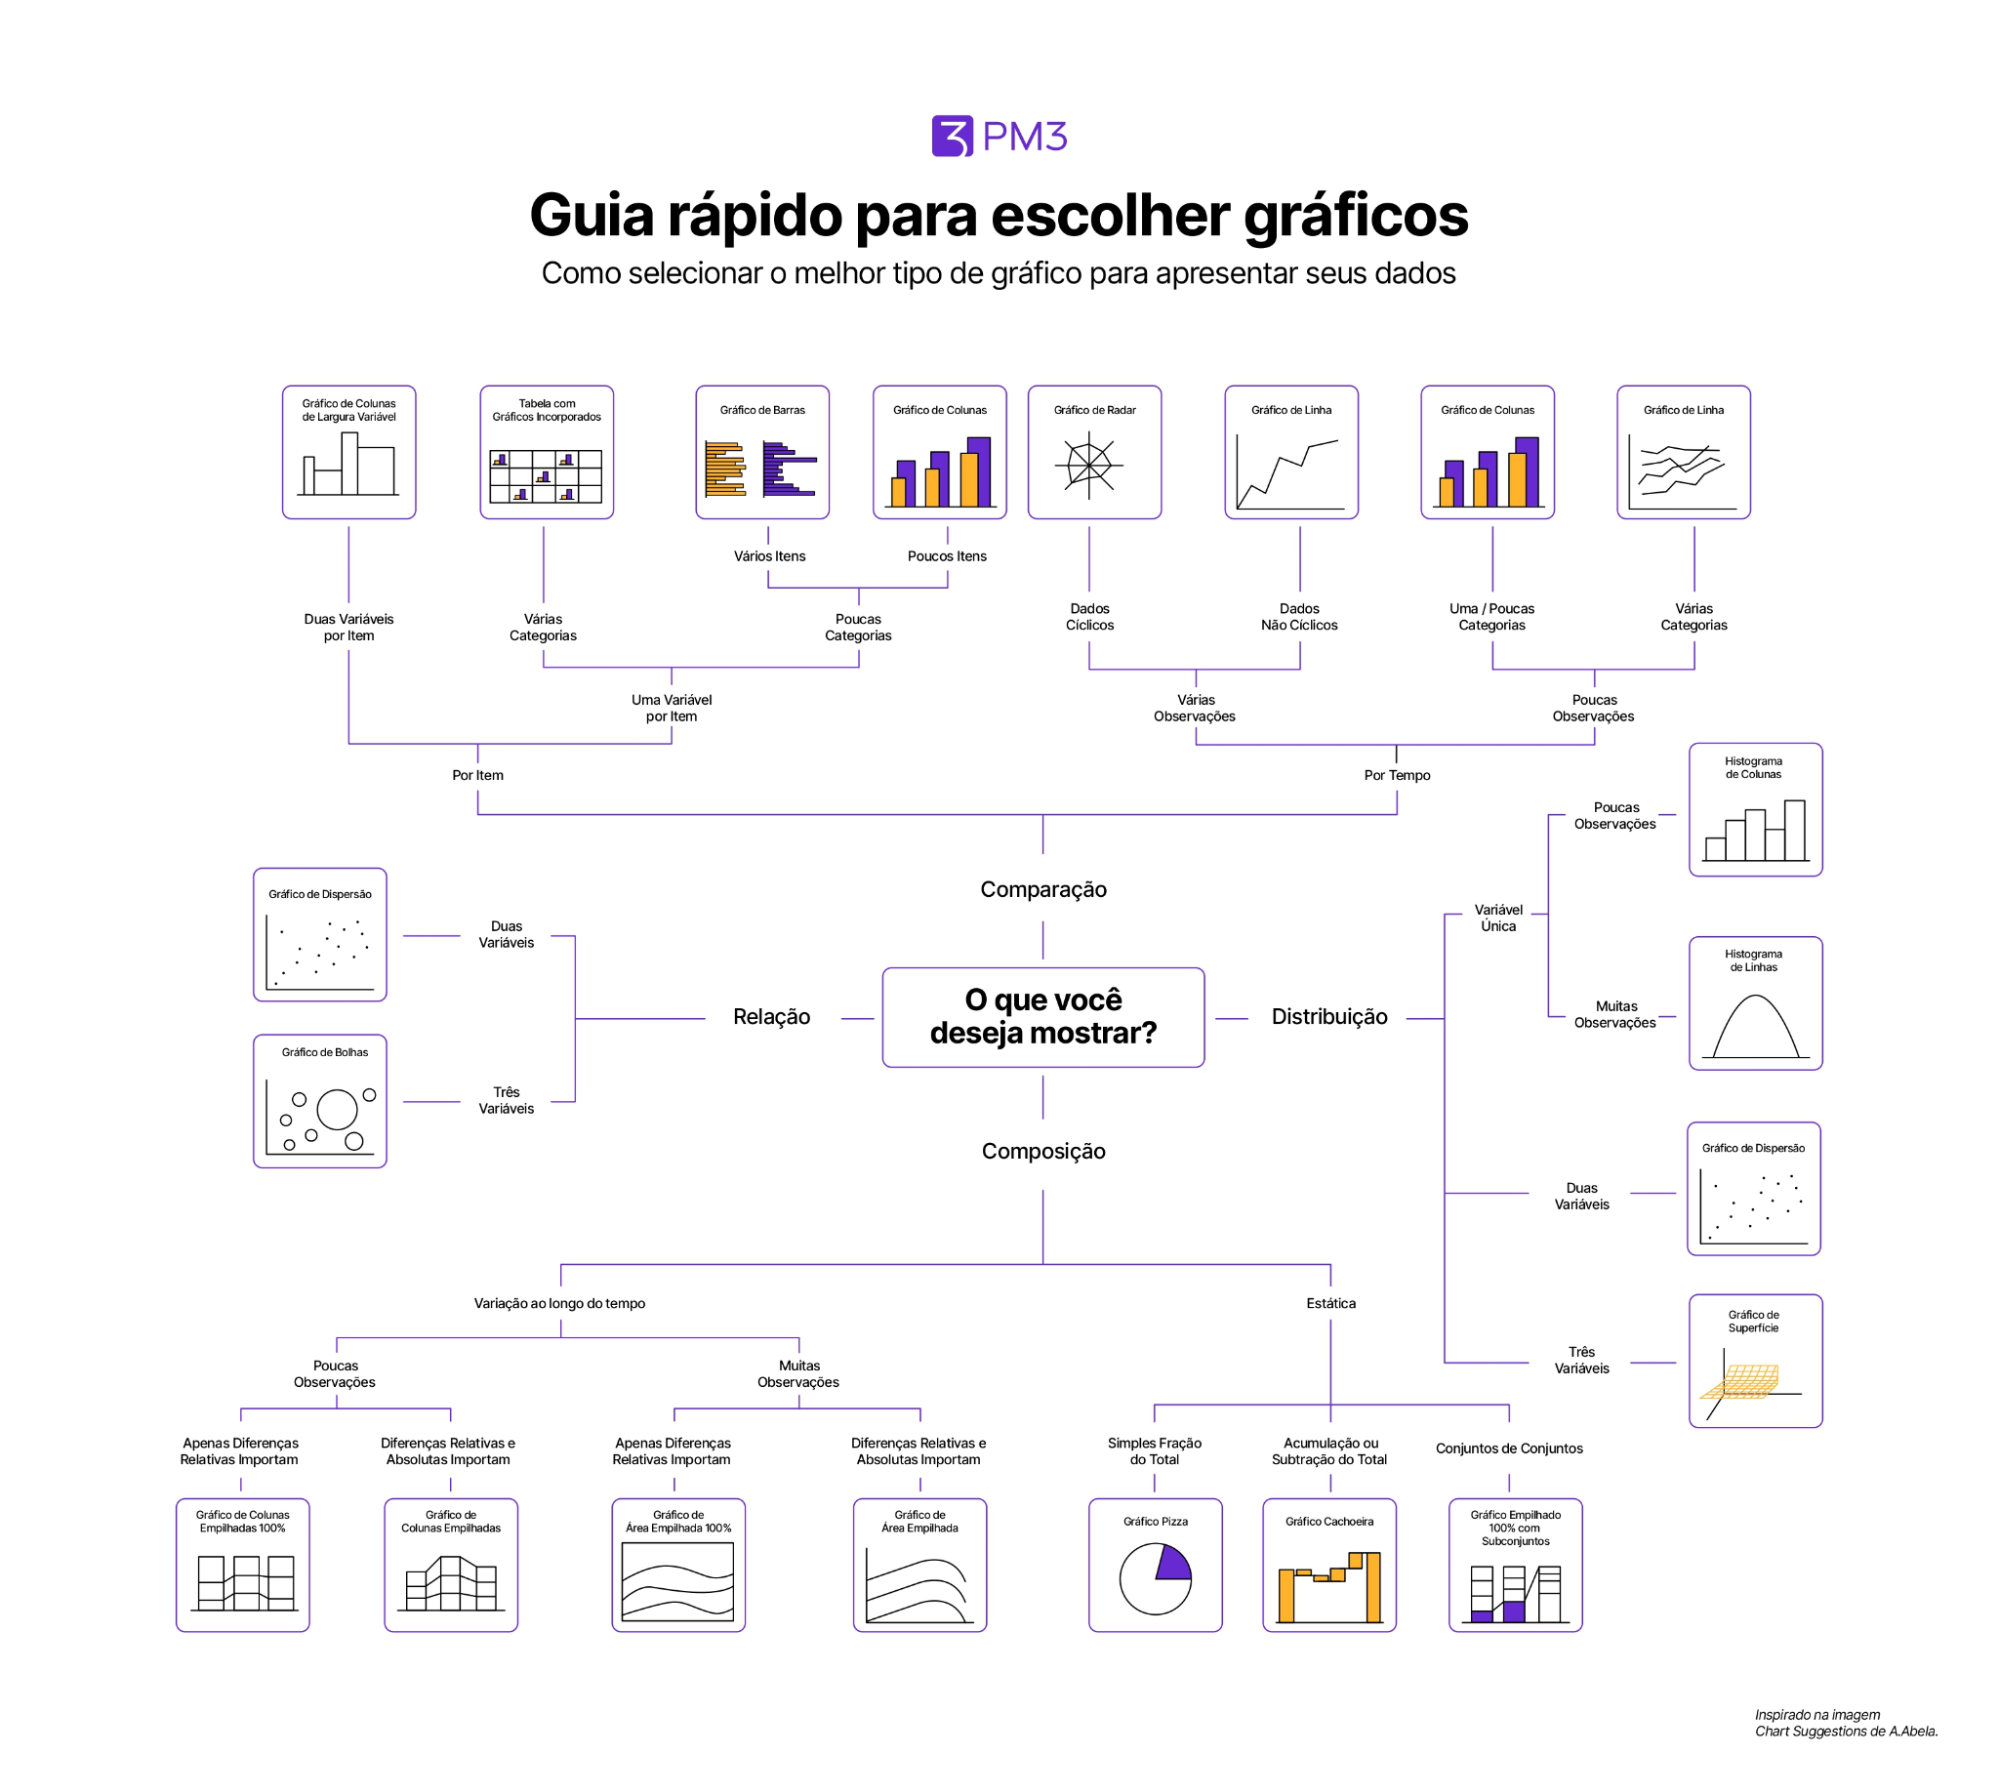

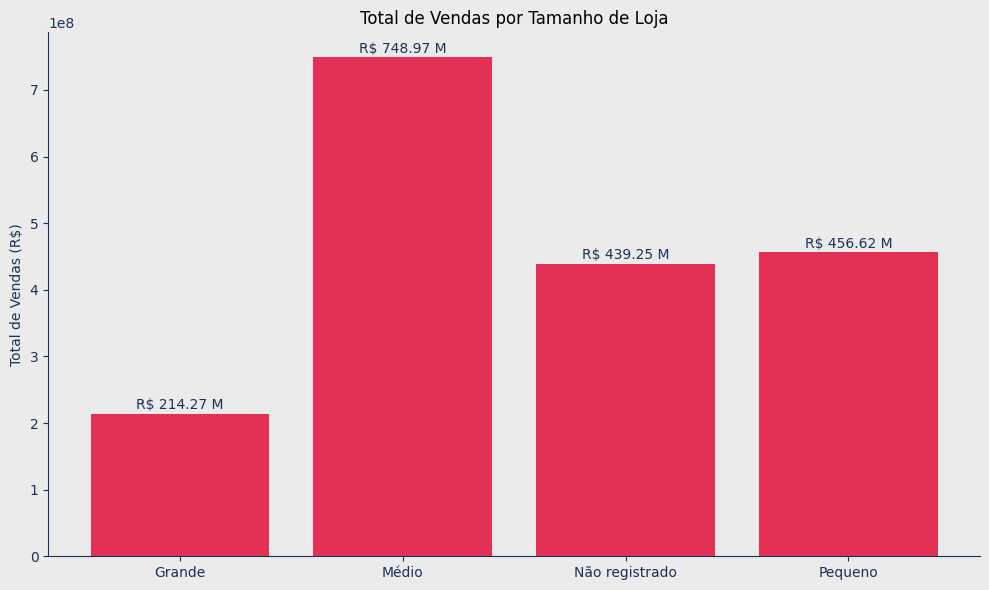

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Crie um DataFrame com os dados agrupados por tamanho de loja
df_agrupado = df.groupby('loja_tamanho')['vendas_totais'].sum().reset_index()

# Cores
cor_fundo = "#ebebeb"
cor_barras = "#e23155"
cor_texto = "#19325c"

# Crie a figura e o eixo
fig, ax = plt.subplots(figsize=(10, 6))
fig.set_facecolor(cor_fundo)
ax.set_facecolor(cor_fundo)

# Plote as barras
barras = ax.bar(df_agrupado['loja_tamanho'], df_agrupado['vendas_totais'], color=cor_barras)

# Adicione o total de vendas acima de cada barra
for bar in barras:
    altura_barra = bar.get_height()
    valor_vendas = altura_barra / 1000000  # Converter para milhões
    ax.annotate(f'R$ {valor_vendas:.2f} M', xy=(bar.get_x() + bar.get_width() / 2, altura_barra),
                xytext=(0, 3), textcoords='offset points', ha='center', color=cor_texto)

# Configurações adicionais
ax.set_ylabel('Total de Vendas (R$)')
ax.set_title('Total de Vendas por Tamanho de Loja')
plt.xticks(rotation=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color(cor_texto)
ax.spines['left'].set_color(cor_texto)
ax.tick_params(axis='x', colors=cor_texto)
ax.tick_params(axis='y', colors=cor_texto)
ax.yaxis.label.set_color(cor_texto)
ax.xaxis.label.set_color(cor_texto)

# Exibir o gráfico
plt.tight_layout()
plt.show()


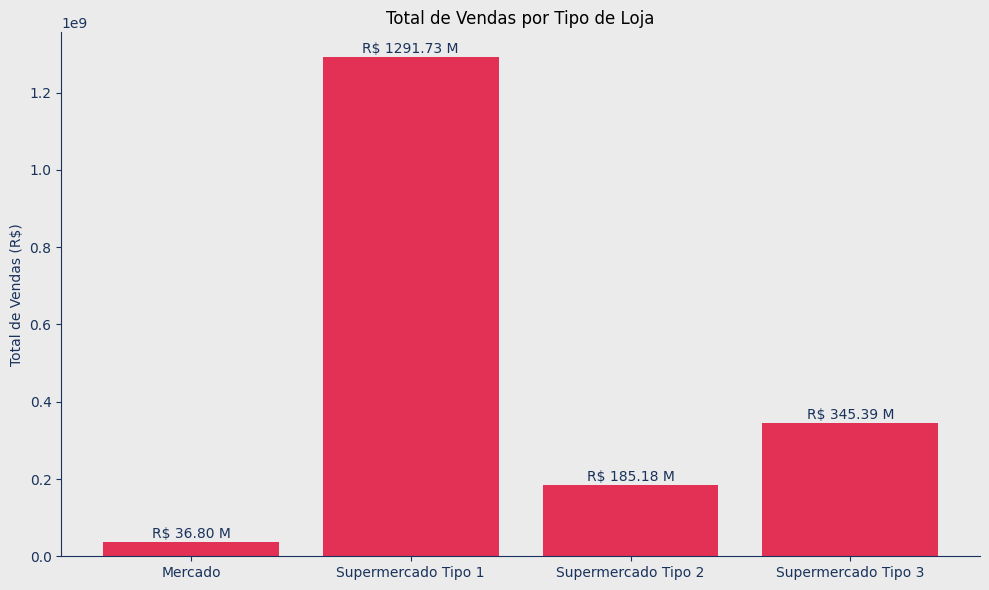

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Crie um DataFrame com os dados agrupados por tipo de loja
df_agrupado = df.groupby('loja_tipo')['vendas_totais'].sum().reset_index()

# Cores
cor_fundo = "#ebebeb"
cor_barras = "#e23155"
cor_texto = "#19325c"

# Crie a figura e o eixo
fig, ax = plt.subplots(figsize=(10, 6))
fig.set_facecolor(cor_fundo)
ax.set_facecolor(cor_fundo)

# Plote as barras
barras = ax.bar(df_agrupado['loja_tipo'], df_agrupado['vendas_totais'], color=cor_barras)

# Adicione o total de vendas acima de cada barra
for bar in barras:
    altura_barra = bar.get_height()
    valor_vendas = altura_barra / 1000000  # Converter para milhões
    ax.annotate(f'R$ {valor_vendas:.2f} M', xy=(bar.get_x() + bar.get_width() / 2, altura_barra),
                xytext=(0, 3), textcoords='offset points', ha='center', color=cor_texto)

# Configurações adicionais
ax.set_ylabel('Total de Vendas (R$)')
ax.set_title('Total de Vendas por Tipo de Loja')
plt.xticks(rotation=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color(cor_texto)
ax.spines['left'].set_color(cor_texto)
ax.tick_params(axis='x', colors=cor_texto)
ax.tick_params(axis='y', colors=cor_texto)
ax.yaxis.label.set_color(cor_texto)
ax.xaxis.label.set_color(cor_texto)

# Exibir o gráfico
plt.tight_layout()
plt.show()

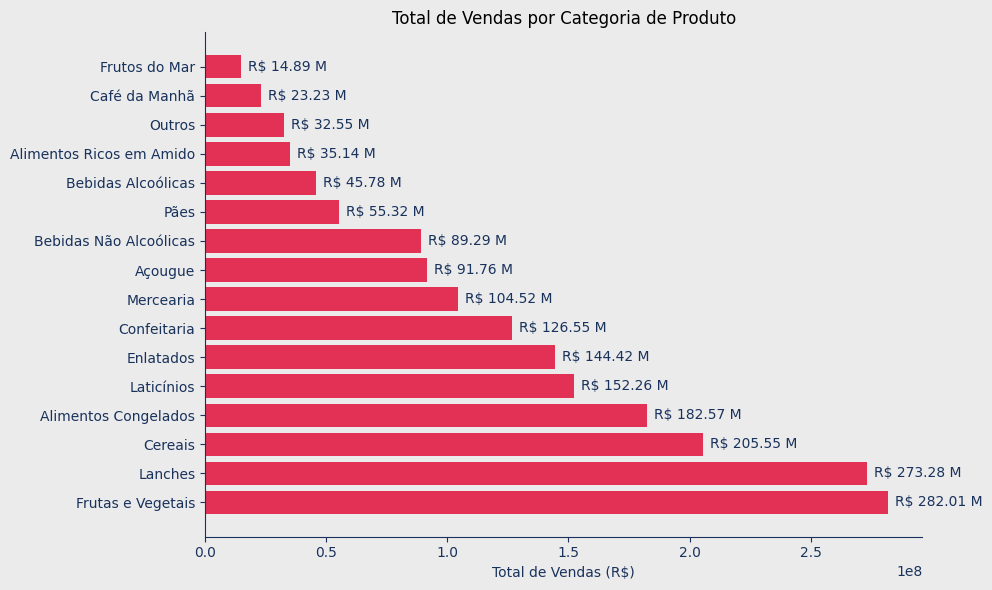

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Crie um DataFrame com os dados agrupados por categoria de produto
df_agrupado = df.groupby('item_tipo')['vendas_totais'].sum().reset_index()

# Cores
cor_fundo = "#ebebeb"
cor_barras = "#e23155"
cor_texto = "#19325c"

# Ordenar o DataFrame por vendas totais (funil)
df_agrupado = df_agrupado.sort_values(by='vendas_totais', ascending=True)

# Crie a figura e o eixo
fig, ax = plt.subplots(figsize=(10, 6))
fig.set_facecolor(cor_fundo)
ax.set_facecolor(cor_fundo)

# Plote as barras horizontais
barras = ax.barh(df_agrupado['item_tipo'], df_agrupado['vendas_totais'], color=cor_barras)

# Adicione o total de vendas dentro de cada barra
for bar in barras:
    largura_barra = bar.get_width()
    valor_vendas = largura_barra / 1000000  # Converter para milhões
    ax.annotate(f'R$ {valor_vendas:.2f} M', xy=(largura_barra, bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0), textcoords='offset points', va='center', color=cor_texto)

# Configurações adicionais
ax.set_xlabel('Total de Vendas (R$)')
ax.set_title('Total de Vendas por Categoria de Produto')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color(cor_texto)
ax.spines['left'].set_color(cor_texto)
ax.tick_params(axis='x', colors=cor_texto)
ax.tick_params(axis='y', colors=cor_texto)
ax.xaxis.label.set_color(cor_texto)
ax.yaxis.label.set_color(cor_texto)
ax.grid(False)

# Inverter a ordem das categorias de produtos para manter o aspecto de funil
ax.invert_yaxis()

# Exibir o gráfico
plt.tight_layout()
plt.show()


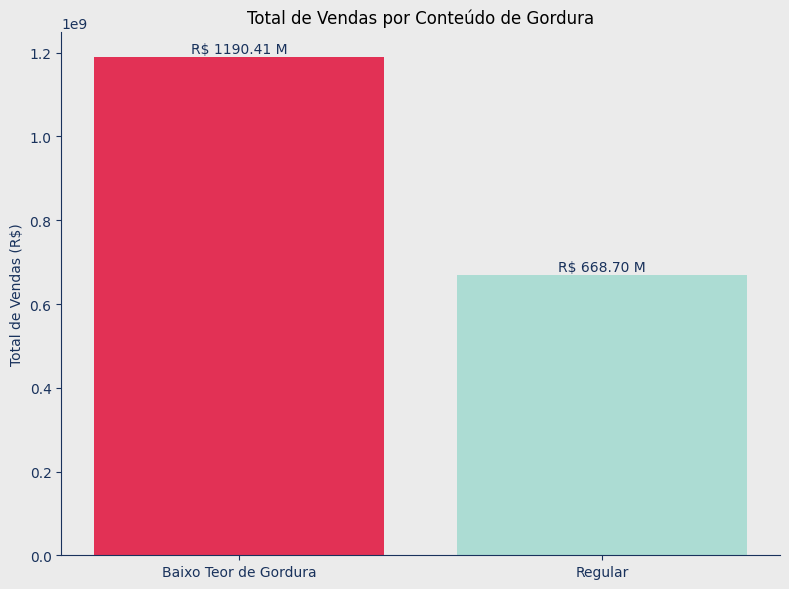

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Crie um DataFrame com os dados agrupados por categoria de quantidade de gordura
df_agrupado = df.groupby('item_conteudo_gordura')['vendas_totais'].sum().reset_index()

# Cores
cor_fundo = "#ebebeb"
cor_baixo_gordura = "#e23155"
cor_regular = "#acdcd3"
cor_texto = "#19325c"

# Crie a figura e o eixo
fig, ax = plt.subplots(figsize=(8, 6))
fig.set_facecolor(cor_fundo)
ax.set_facecolor(cor_fundo)

# Plote as colunas
barras = ax.bar(df_agrupado['item_conteudo_gordura'], df_agrupado['vendas_totais'],
                color=[cor_baixo_gordura, cor_regular])

# Adicione o total de vendas acima de cada coluna
for bar in barras:
    altura_barra = bar.get_height()
    valor_vendas = altura_barra / 1000000  # Converter para milhões
    ax.annotate(f'R$ {valor_vendas:.2f} M', xy=(bar.get_x() + bar.get_width() / 2, altura_barra),
                xytext=(0, 3), textcoords='offset points', ha='center', color=cor_texto)

# Configurações adicionais
ax.set_ylabel('Total de Vendas (R$)')
ax.set_title('Total de Vendas por Conteúdo de Gordura')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color(cor_texto)
ax.spines['left'].set_color(cor_texto)
ax.tick_params(axis='x', colors=cor_texto)
ax.tick_params(axis='y', colors=cor_texto)
ax.xaxis.label.set_color(cor_texto)
ax.yaxis.label.set_color(cor_texto)
ax.grid(False)

# Exibir o gráfico
plt.tight_layout()
plt.show()